In [1]:
from ModelClass import RegressionModel
from DatasetClass import Dataset, DatasetMass
from src.helpers import pick_only_target, extract_data
import matplotlib.pyplot as plt
import numpy as np
import itertools
from src.helpers import make_filter_slice
import tensorflow as tf
#import optuna 
#from optuna_dashboard import run_server
import threading



2025-05-26 11:54:54.867863: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748253294.979084 1328766 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748253295.025301 1328766 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-26 11:54:55.427401: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Available GPUs: []


2025-05-26 11:55:02.742896: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [2]:
erik_data = "/scratch/ucjf-atlas/htautau/SM_Htautau_R22/V02_skim_mva_01/*/*/*/*/*H125*.root"
patrik_data = "/scratch/ucjf-atlas/htautau/SM_Htautau_R22/V02_skim_mva_01/*/*/*/*/*Ztt*.root"

In [32]:
dataset = DatasetMass(file_paths = erik_data)
dataset.load_data(file_name= "data_h125")
#dataset.augment_data_phi(n_slices=25)

print(dataset.train_events)
print(dataset.val_events)
print(dataset.dev_events)
print(dataset.train_events + dataset.val_events + dataset.dev_events) 

6523684
815463
815460
8154607


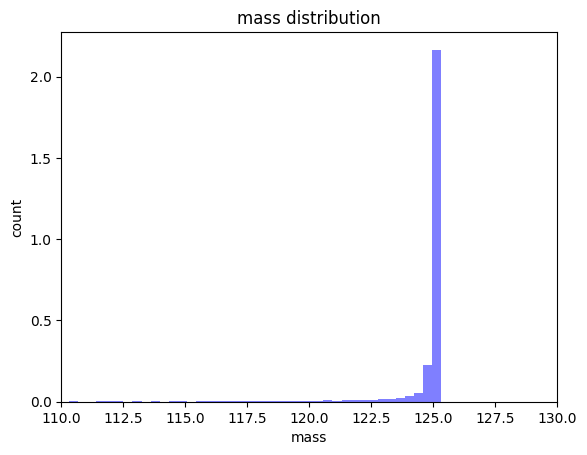

In [10]:
for mass, target in dataset.train_dataset.batch(10000).take(1):
    break

plt.hist(target.numpy(), bins=1000, density=True, alpha=0.5, color='blue', label='target')
plt.xlim(110, 130)
plt.xlabel("mass")
plt.ylabel("count")
plt.title("mass distribution")
plt.show()


In [5]:
dataset = DatasetMass(file_paths=erik_data)
dataset.load_data(file_name = "data_h125")
#dataset.augment_data(n_slices = 25)
model = RegressionModel(dataset=dataset)
#model.load(model_name="PatrikNet_mmc_phi_flattened_lorentz_30cpus.keras") #best one so far
model.load(model_name="PatrikNet_phi_flattened_30s_40_180.keras")

y_pred = model.model.predict(dataset.val_dataset.batch(10000)).squeeze()

#plt.hist(data, bins=100, range=(50, 130), histtype='step', label='pt distribution', density=False)
#plt.legend(loc='upper right')
#plt.title('pt distribution of the dataset')
#plt.xlabel('pt')
#plt.ylabel('Number of events')
#plt.show()

#features, masses = next(iter(dataset.train_dataset.batch(1000)))

#print(features.shape)
#print(features)

#plt.hist(masses, range=(70, 130), bins=50)
#plt.show()



Number of devices: 1
Model loaded from /home/ivanpa/HiggsAnalysisBc/models/PatrikNet_phi_flattened_30s_40_180.keras


I0000 00:00:1748253387.711710 1328894 service.cc:148] XLA service 0x7f9fec005f50 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748253387.712168 1328894 service.cc:156]   StreamExecutor device (0): Host, Default Version
2025-05-26 11:56:27.748393: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


 1/82 ━━━━━━━━━━━━━━━━━━━━ 1:42 1s/step

I0000 00:00:1748253388.134043 1328894 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


82/82 ━━━━━━━━━━━━━━━━━━━━ 23s 263ms/step


In [16]:
dataset_Ztt = DatasetMass(file_paths=erik_data)
dataset_Ztt.load_data(file_name = "data_mmc")
model = RegressionModel(dataset=dataset_Ztt)
model.load(model_name="PatrikNet_phi_flattened_30s_40_180.keras")
y_pred_Ztt = model.model.predict(dataset_Ztt.val_dataset.batch(10000)).squeeze()


Number of devices: 1
Model loaded from /home/ivanpa/HiggsAnalysisBc/models/PatrikNet_phi_flattened_30s_40_180.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 26s 258ms/step



--- True Distribution (y_pred_Ztt) ---
Peak Position (Mean): 95.716
FWHM: 20.300

--- Predicted Distribution (y_pred) ---
Peak Position (Mean): 125.305
FWHM: 40.740


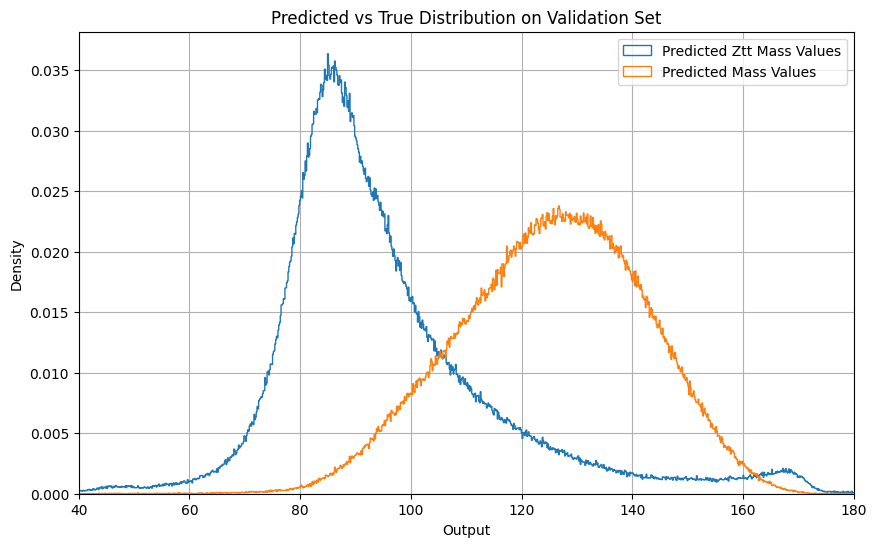

In [ ]:
hist_bins = np.linspace(40.0, 180.0, 1001) # 1000 bins -> 1001 edges

print("\n--- True Distribution (y_pred_Ztt) ---")

counts_true, bin_edges_true = np.histogram(y_pred_Ztt, bins=hist_bins, density=True)
bin_centers_true = (bin_edges_true[:-1] + bin_edges_true[1:]) / 2
max_density_true = np.max(counts_true)
peak_position_true = np.mean(y_pred_Ztt)
print(f"Peak Position (Mean): {peak_position_true:.3f}")
half_max_true = max_density_true / 2.0
half_max_indices_true = np.where(counts_true >= half_max_true)[0]

if len(half_max_indices_true) > 1:
    fwhm_start_index_true = half_max_indices_true[0]
    fwhm_end_index_true = half_max_indices_true[-1]
    fwhm_true = bin_centers_true[fwhm_end_index_true] - bin_centers_true[fwhm_start_index_true]
    print(f"FWHM: {fwhm_true:.3f}")
else:
    print("Could not calculate FWHM for True distribution (distribution might be too narrow, spread out, or has multiple peaks).")

# --- Calculations for the Predicted Distribution (y_pred) ---
print("\n--- Predicted Distribution (y_pred) ---")

counts_pred, bin_edges_pred = np.histogram(y_pred, bins=hist_bins, density=True)
bin_centers_pred = (bin_edges_pred[:-1] + bin_edges_pred[1:]) / 2
max_density_pred = np.max(counts_pred)
peak_position_pred = np.mean(y_pred)
print(f"Peak Position (Mean): {peak_position_pred:.3f}")

half_max_pred = max_density_pred / 2.0
half_max_indices_pred = np.where(counts_pred >= half_max_pred)[0]

if len(half_max_indices_pred) > 1:
    fwhm_start_index_pred = half_max_indices_pred[0]
    fwhm_end_index_pred = half_max_indices_pred[-1]
    fwhm_pred = bin_centers_pred[fwhm_end_index_pred] - bin_centers_pred[fwhm_start_index_pred]
    print(f"FWHM: {fwhm_pred:.3f}")
else:
     print("Could not calculate FWHM for Predicted distribution (distribution might be too narrow, spread out, or has multiple peaks).")

# --- Your plotting code ---
plt.figure(figsize=(10, 6))
plt.hist(y_pred_Ztt, bins=hist_bins, histtype='step', label=f'Predicted Ztt Mass Values', density=True)
plt.hist(y_pred, bins=hist_bins, histtype='step', label=f'Predicted Mass Values', density=True)
plt.xlabel("Output")
plt.ylabel("Density")
plt.xlim(40, 180)
plt.title("Predicted Ztt vs predicted H125 Distribution on Validation Set")
plt.legend()
plt.grid(True)
plt.savefig("predicted_vs_true_distribution.png", dpi=300)

In [4]:
@tf.function
def pick_only_mmc(data, label):
    return data[-1]

#y_true_h125 = np.array(extract_data(dataset.val_dataset.map(pick_only_mmc)))
y_true_Ztt = np.array(extract_data(dataset_Ztt.val_dataset.map(pick_only_mmc)))
#y_pred = model.model.predict(dataset.val_dataset.batch(1000)).squeeze()


2025-05-23 18:00:07.417462: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [33]:
print(np.std(y_true_Ztt))
print(np.max(y_true_Ztt))

5.000799332013302
113.39542125512878


In [32]:
counts_Ztt, bin_edges_Ztt = np.histogram(y_true_Ztt, bins=200, density=True)
bin_centers_Ztt = (bin_edges_Ztt[:-1] + bin_edges_Ztt[1:]) / 2
max_density_Ztt = np.max(counts_Ztt)
peak_position_Ztt = np.mean(y_true_Ztt)
print(f"Peak Position (Mean): {peak_position_Ztt:.3f}")

half_max_Ztt = max_density_Ztt / 2.0
half_max_indices_Ztt = np.where(counts_Ztt >= half_max_Ztt)[0]

if len(half_max_indices_Ztt) > 1:
    fwhm_start_index_Ztt = half_max_indices_Ztt[0]
    fwhm_end_index_Ztt = half_max_indices_Ztt[-1]
    fwhm_Ztt = bin_centers_Ztt[fwhm_end_index_Ztt] - bin_centers_Ztt[fwhm_start_index_Ztt]
    print(f"FWHM: {fwhm_Ztt:.3f}")
else:
     print("Could not calculate FWHM for Predicted distribution (distribution might be too narrow, spread out, or has multiple peaks).")

# --- Your plotting code ---
plt.figure(figsize=(10, 6))
#plt.hist(y_pred_Ztt, bins=hist_bins, histtype='step', label=f'Predicted Ztt Mass Values', density=True)
plt.hist(y_true_Ztt, bins=200, histtype='step', label=f'Ztt MMC values', density=True)
#plt.axhline(y = bin_centers_Ztt[fwhm_end_index_Ztt])
plt.xlabel("Mass [GeV]")
plt.ylabel("Density")
plt.xlim(60, 130)
#plt.title("Predicted vs True Distribution on Validation Set")
plt.legend()
#plt.grid(True)
plt.savefig("Ztt_True.png", dpi=300)

Peak Position (Mean): 90.998
FWHM: 11.181



--- Loading H125 Dataset (data_h125) ---

--- Loading Ztt Dataset (data_mmc) ---

--- Inspecting raw MMC values from H125 dataset ---
H125 Sample 0: MMC = 115.866
H125 Sample 1: MMC = 99.322
H125 Sample 2: MMC = 162.216
H125 Sample 3: MMC = 144.136
H125 Sample 4: MMC = 132.210
First 5 H125 MMC values: [np.float32(115.8655), np.float32(99.321686), np.float32(162.21606), np.float32(144.1363), np.float32(132.21034)]

--- Inspecting raw MMC values from Ztt dataset ---
Ztt Sample 0: MMC = 73.342
Ztt Sample 1: MMC = 86.999
Ztt Sample 2: MMC = 0.000
Ztt Sample 3: MMC = 88.992
Ztt Sample 4: MMC = 76.069
First 5 Ztt MMC values: [np.float32(73.34158), np.float32(86.99927), np.float32(0.0), np.float32(88.99236), np.float32(76.069214)]


2025-05-26 12:00:10.853627: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-05-26 12:00:10.887816: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-05-26 12:03:07.570590: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Mean of y_true_h125: 119.563
Mean of y_true_Ztt: 91.746

y_true_h125 and y_true_Ztt arrays are different. The issue might be in how you interpret the plot.


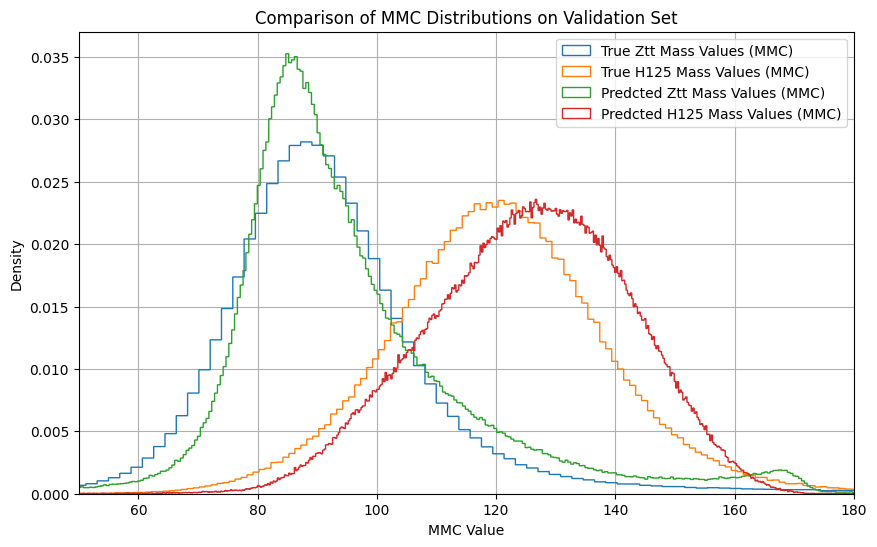

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Assume DatasetMass, RegressionModel, and extract_data are defined as in your environment
# Assume erik_data is defined

# --- Dataset for H125 ---
print("\n--- Loading H125 Dataset (data_h125) ---")
dataset_h125_obj = DatasetMass(file_paths=erik_data)
dataset_h125_obj.load_data(file_name="data_h125")

# --- Dataset for Ztt ---
print("\n--- Loading Ztt Dataset (data_mmc) ---")
dataset_Ztt_obj = DatasetMass(file_paths=erik_data)
dataset_Ztt_obj.load_data(file_name="data_mmc")

@tf.function
def pick_only_mmc(data, label):
    # This function extracts the last element of the 'data' tensor
    return data[-1]

print("\n--- Inspecting raw MMC values from H125 dataset ---")
# Take a few samples and print their MMC values
sample_mmc_h125 = []
for i, (data_features, data_label) in enumerate(dataset_h125_obj.val_dataset.take(5)): # Take 5 samples
    mmc_value = data_features[-1].numpy()
    sample_mmc_h125.append(mmc_value)
    print(f"H125 Sample {i}: MMC = {mmc_value:.3f}")
print(f"First 5 H125 MMC values: {sample_mmc_h125}")


print("\n--- Inspecting raw MMC values from Ztt dataset ---")
sample_mmc_Ztt = []
for i, (data_features, data_label) in enumerate(dataset_Ztt_obj.val_dataset.take(5)): # Take 5 samples
    mmc_value = data_features[-1].numpy()
    sample_mmc_Ztt.append(mmc_value)
    print(f"Ztt Sample {i}: MMC = {mmc_value:.3f}")
print(f"First 5 Ztt MMC values: {sample_mmc_Ztt}")

# Now, extract all MMC values
y_true_h125 = np.array(extract_data(dataset_h125_obj.val_dataset.map(pick_only_mmc)))
y_true_Ztt = np.array(extract_data(dataset_Ztt_obj.val_dataset.map(pick_only_mmc)))

print(f"\nMean of y_true_h125: {np.mean(y_true_h125):.3f}")
print(f"Mean of y_true_Ztt: {np.mean(y_true_Ztt):.3f}")

# Your plotting code
plt.figure(figsize=(10, 6))
plt.hist(y_true_Ztt, bins=1000, histtype='step', label=f'True Ztt Mass Values (MMC)', density=True)
plt.hist(y_true_h125, bins=1000, histtype='step', label=f'True H125 Mass Values (MMC)', density=True)
plt.hist(y_pred_Ztt, bins=1000, histtype='step', label=f'Predcted Ztt Mass Values (MMC)', density=True)
plt.hist(y_pred, bins=1000, histtype='step', label=f'Predcted H125 Mass Values (MMC)', density=True)
plt.xlabel("MMC Value")
plt.ylabel("Density")
plt.xlim(50, 180)
plt.title("Comparison of MMC Distributions on Validation Set")
plt.legend()
plt.grid(True)
plt.savefig("mmc_distribution_comparison.png", dpi=300)

# --- Rest of your original code if needed for prediction comparison ---
# y_pred = model.model.predict(dataset_h125_obj.val_dataset.batch(10000)).squeeze()
# y_pred_Ztt = model.model.predict(dataset_Ztt_obj.val_dataset.batch(10000)).squeeze()

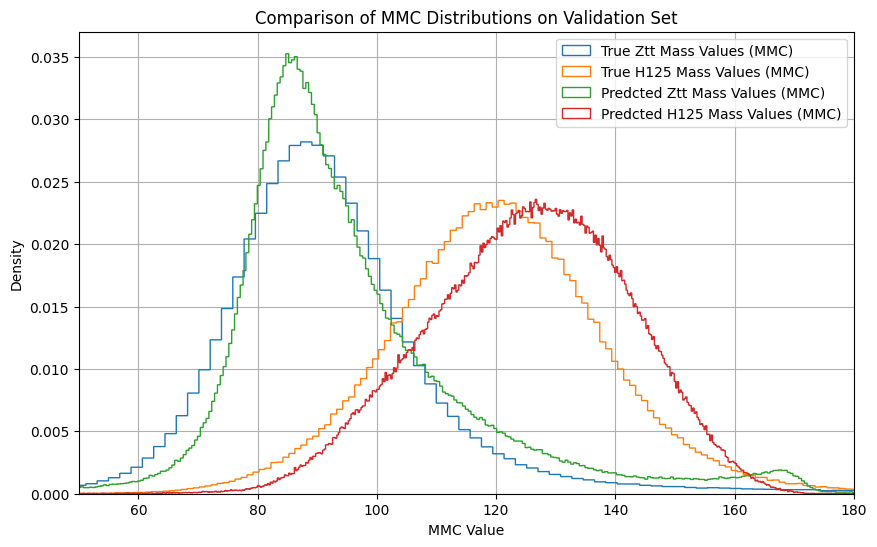

In [21]:
plt.figure(figsize=(10, 6))
plt.hist(y_true_Ztt, bins=1000, histtype='step', label=f'True Ztt Mass Values (MMC)', density=True)
plt.hist(y_true_h125, bins=1000, histtype='step', label=f'True H125 Mass Values (MMC)', density=True)
plt.hist(y_pred_Ztt, bins=1000, histtype='step', label=f'Predcted Ztt Mass Values (MMC)', density=True)
plt.hist(y_pred, bins=1000, histtype='step', label=f'Predcted H125 Mass Values (MMC)', density=True)
plt.xlabel("MMC Value")
plt.ylabel("Density")
plt.xlim(50, 180)
plt.title("Comparison of MMC Distributions on Validation Set")
plt.legend()
plt.grid(True)
plt.savefig("mmc_distribution_comparison.png", dpi=300)


--- True Distribution (y_true_h125) ---
Peak Position (Mean): 91.746
FWHM: 28.470

--- Predicted Distribution (y_true_Ztt) ---
Peak Position (Mean): 91.746
FWHM: 28.470


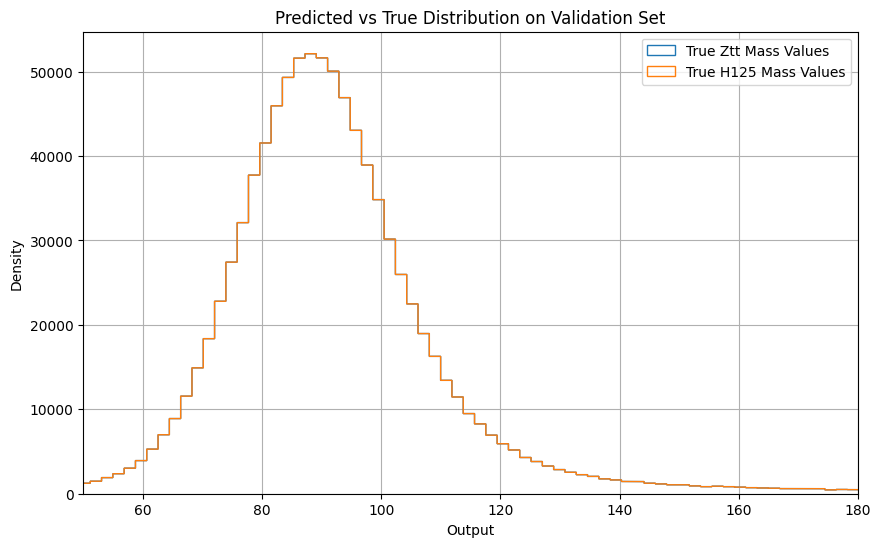

In [ ]:
hist_bins = np.linspace(50.0, 180.0, 1001) # 1000 bins -> 1001 edges

print("\n--- True Distribution (y_true_h125) ---")

counts_true, bin_edges_true = np.histogram(y_true_h125, bins=hist_bins, density=True)
bin_centers_true = (bin_edges_true[:-1] + bin_edges_true[1:]) / 2
max_density_true = np.max(counts_true)
peak_position_true = np.mean(y_true_h125)
print(f"Peak Position (Mean): {peak_position_true:.3f}")
half_max_true = max_density_true / 2.0
half_max_indices_true = np.where(counts_true >= half_max_true)[0]

if len(half_max_indices_true) > 1:
    fwhm_start_index_true = half_max_indices_true[0]
    fwhm_end_index_true = half_max_indices_true[-1]
    fwhm_true = bin_centers_true[fwhm_end_index_true] - bin_centers_true[fwhm_start_index_true]
    print(f"FWHM: {fwhm_true:.3f}")
else:
    print("Could not calculate FWHM for True distribution (distribution might be too narrow, spread out, or has multiple peaks).")

# --- Calculations for the Predicted Distribution (y_pred) ---
print("\n--- Predicted Distribution (y_true_Ztt) ---")

counts_pred, bin_edges_pred = np.histogram(y_true_Ztt, bins=hist_bins, density=True)
bin_centers_pred = (bin_edges_pred[:-1] + bin_edges_pred[1:]) / 2
max_density_pred = np.max(counts_pred)
peak_position_pred = np.mean(y_true_Ztt)
print(f"Peak Position (Mean): {peak_position_pred:.3f}")

half_max_pred = max_density_pred / 2.0
half_max_indices_pred = np.where(counts_pred >= half_max_pred)[0]

if len(half_max_indices_pred) > 1:
    fwhm_start_index_pred = half_max_indices_pred[0]
    fwhm_end_index_pred = half_max_indices_pred[-1]
    fwhm_pred = bin_centers_pred[fwhm_end_index_pred] - bin_centers_pred[fwhm_start_index_pred]
    print(f"FWHM: {fwhm_pred:.3f}")
else:
     print("Could not calculate FWHM for Predicted distribution (distribution might be too narrow, spread out, or has multiple peaks).")

# --- Your plotting code ---
plt.figure(figsize=(10, 6))
plt.hist(y_true_Ztt, bins=1000, histtype='step', label=f'True Ztt Mass Values', density=True)
plt.hist(y_true_h125, bins=1000, histtype='step', label=f'True H125 Mass Values', density=True)
plt.xlabel("Output")
plt.ylabel("Density")
plt.xlim(50, 180)
plt.title("Predicted vs True Distribution on Validation Set")
plt.legend()
plt.grid(True)
plt.savefig("predicted_vs_true_distribution.png", dpi=300)

In [6]:
y_target = np.array(extract_data(dataset.val_dataset.map(pick_only_target)))

2025-05-23 15:18:32.134060: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [15]:
std_true = np.std(y_true)
std_pred = np.std(y_pred)
mean_target = np.mean(y_true)
mean_pred = np.mean(y_pred) 
print("std_target: ", std_true)
print("std_pred: ", std_pred)
print("mean_target: ", mean_target)
print("mean_pred: ", mean_pred)

std_target:  23.939556
std_pred:  7.340717
mean_target:  119.56338
mean_pred:  120.7758



--- True Distribution (y_true) ---
Peak Position (Mean): 119.563
FWHM: 37.290

--- Predicted Distribution (y_pred) ---
Peak Position (Mean): 120.776
FWHM: 16.390


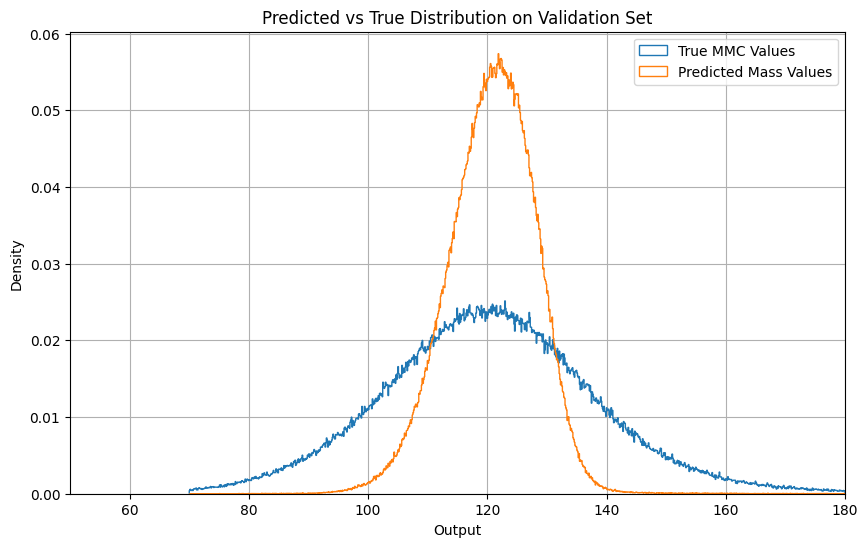

In [ ]:
hist_bins = np.linspace(70.0, 180.0, 1001) # 1000 bins -> 1001 edges

print("\n--- True Distribution (y_true) ---")

counts_true, bin_edges_true = np.histogram(y_true, bins=hist_bins, density=True)
bin_centers_true = (bin_edges_true[:-1] + bin_edges_true[1:]) / 2
max_density_true = np.max(counts_true)
peak_position_true = np.mean(y_true)
print(f"Peak Position (Mean): {peak_position_true:.3f}")
half_max_true = max_density_true / 2.0
half_max_indices_true = np.where(counts_true >= half_max_true)[0]

if len(half_max_indices_true) > 1:
    fwhm_start_index_true = half_max_indices_true[0]
    fwhm_end_index_true = half_max_indices_true[-1]
    fwhm_true = bin_centers_true[fwhm_end_index_true] - bin_centers_true[fwhm_start_index_true]
    print(f"FWHM: {fwhm_true:.3f}")
else:
    print("Could not calculate FWHM for True distribution (distribution might be too narrow, spread out, or has multiple peaks).")

# --- Calculations for the Predicted Distribution (y_pred) ---
print("\n--- Predicted Distribution (y_pred) ---")

counts_pred, bin_edges_pred = np.histogram(y_pred, bins=hist_bins, density=True)
bin_centers_pred = (bin_edges_pred[:-1] + bin_edges_pred[1:]) / 2
max_density_pred = np.max(counts_pred)
peak_position_pred = np.mean(y_pred)
print(f"Peak Position (Mean): {peak_position_pred:.3f}")

half_max_pred = max_density_pred / 2.0
half_max_indices_pred = np.where(counts_pred >= half_max_pred)[0]

if len(half_max_indices_pred) > 1:
    fwhm_start_index_pred = half_max_indices_pred[0]
    fwhm_end_index_pred = half_max_indices_pred[-1]
    fwhm_pred = bin_centers_pred[fwhm_end_index_pred] - bin_centers_pred[fwhm_start_index_pred]
    print(f"FWHM: {fwhm_pred:.3f}")
else:
     print("Could not calculate FWHM for Predicted distribution (distribution might be too narrow, spread out, or has multiple peaks).")

# --- Your plotting code ---
plt.figure(figsize=(10, 6))
plt.hist(y_true, bins=hist_bins, histtype='step', label=f'True MMC Values', density=True)
plt.hist(y_pred, bins=hist_bins, histtype='step', label=f'Predicted Mass Values', density=True)
plt.xlabel("Output")
plt.ylabel("Density")
plt.xlim(50, 180)
plt.title("Predicted vs True Distribution on Validation Set")
plt.legend()
plt.grid(True)
plt.savefig("predicted_vs_true_distribution.png", dpi=300)


Residuals Mean: -1.212
Residuals Standard Deviation: 18.156


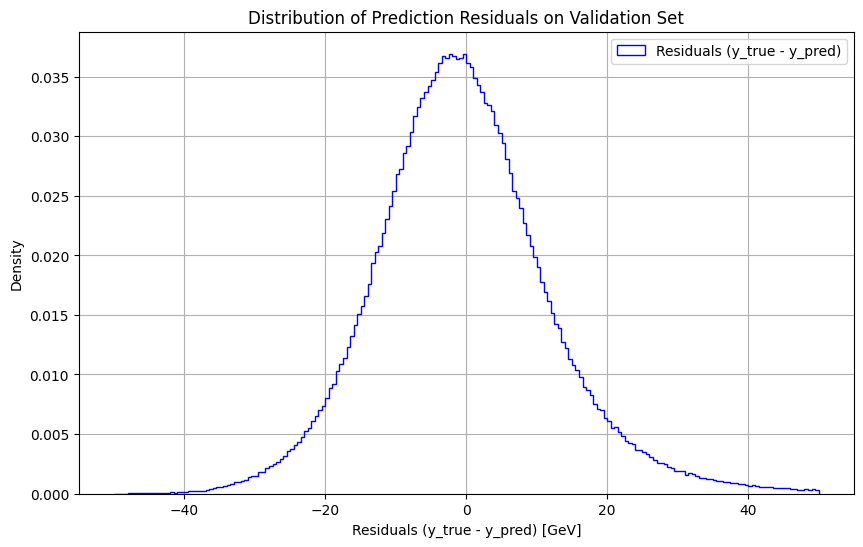

In [28]:

residuals = y_true - y_pred
residual_bins = np.linspace(-50.0, 50.0, 201) # 200 bins

plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=residual_bins, histtype='step', color='blue', label='Residuals (y_true - y_pred)', density=True)

plt.xlabel("Residuals (y_true - y_pred) [GeV]") 
plt.ylabel("Density")
plt.title("Distribution of Prediction Residuals on Validation Set")
plt.legend()
plt.grid(True)
plt.savefig("prediction_residuals_distribution.png", dpi=300)
mean_residual = np.mean(residuals)
std_residual = np.std(residuals)

print(f"\nResiduals Mean: {mean_residual:.3f}")
print(f"Residuals Standard Deviation: {std_residual:.3f}")

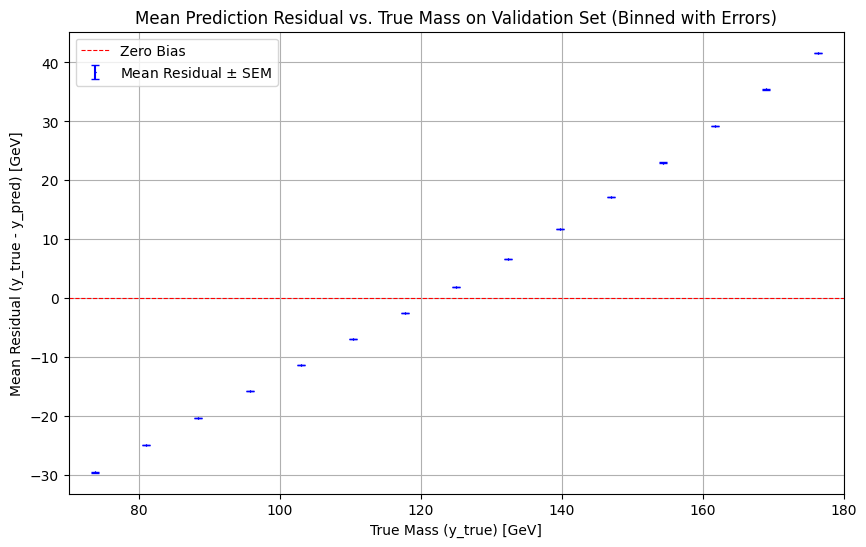

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats # You need scipy for binned_statistic

# Assuming y_true and y_pred are your NumPy arrays of true and predicted values
# Make sure y_true and y_pred have the same length
if len(y_true) != len(y_pred):
    raise ValueError("y_true and y_pred must have the same length")

# Calculate the residuals
residuals = y_true - y_pred

# Define the number of intervals for y_true
# Adjust n_intervals to control the number of points on the plot
n_intervals = 15 # Example: Using 15 intervals

# Define the bin edges for y_true based on the desired intervals
# Use the range relevant to your mass distribution (e.g., 70 to 180 GeV)
true_mass_bins = np.linspace(70.0, 180.0, n_intervals + 1)

# --- Corrected approach: Call binned_statistic for each statistic separately ---

# 1. Calculate the mean residual within each bin of y_true
mean_residuals_per_bin, _, _ = stats.binned_statistic(
    y_true,           # The data to bin by (y_true values)
    residuals,        # The data on which to calculate the statistic (the residuals)
    statistic='mean', # Compute the mean for each bin
    bins=true_mass_bins # The edges defining the bins for y_true
)

# 2. Calculate the standard deviation of residuals within each bin of y_true
std_residuals_per_bin, _, _ = stats.binned_statistic(
    y_true,           # The data to bin by (y_true values)
    residuals,        # The data on which to calculate the statistic (the residuals)
    statistic='std',  # Compute the standard deviation for each bin
    bins=true_mass_bins # The edges defining the bins for y_true
)

# 3. Count the number of samples within each bin of y_true
count_per_bin, _, _ = stats.binned_statistic(
    y_true,           # The data to bin by (y_true values)
    y_true,           # The data to count (can be y_true or residuals, doesn't matter for count)
    statistic='count',# Compute the count for each bin
    bins=true_mass_bins # The edges defining the bins for y_true
)

# Convert count_per_bin to float for division
count_per_bin = count_per_bin.astype(float)

# Calculate the Standard Error of the Mean (SEM) for each bin
# SEM = standard_deviation / sqrt(count)
# Handle cases where count is 0 or 1: std dev is NaN for count=0 or 1 (with ddof=1),
# sqrt(0) is 0, division by zero gives Inf/NaN. SEM will be NaN in these cases.
# np.divide handles division by zero gracefully, returning NaN.
sem_per_bin = np.divide(std_residuals_per_bin, np.sqrt(count_per_bin))


# Calculate the center of each bin. These will be the x-coordinates for our plot points.
bin_centers = (true_mass_bins[:-1] + true_mass_bins[1:]) / 2

# Filter out bins that had no data or only one data point (count <= 1),
# as SEM is not well-defined or is 0 (often not plotted).
valid_indices = count_per_bin > 1

valid_bin_centers = bin_centers[valid_indices]
valid_mean_residuals = mean_residuals_per_bin[valid_indices]
valid_sem = sem_per_bin[valid_indices]


plt.figure(figsize=(10, 6))

# Plot the mean residual vs. the true mass interval center with error bars
# use fmt='o' for discrete points (circles), linestyle='None' to not connect them
plt.errorbar(
    valid_bin_centers,      # X values (bin centers)
    valid_mean_residuals,   # Y values (mean residuals)
    yerr=valid_sem,   
    markersize = 1,      # Y error bars (Standard Error of the Mean)
    fmt='x',                # Format: 'o' for circles, no line
    capsize=3,              # Cap size for the error bars
    color='blue',
    label='Mean Residual $\\pm$ SEM' # Using LaTeX for SEM symbol
)

# Add a horizontal line at y=0 to indicate zero bias
plt.axhline(0, color='red', linestyle='--', linewidth=0.8, label='Zero Bias')

plt.xlabel("True Mass (y_true) [GeV]")
plt.ylabel("Mean Residual (y_true - y_pred) [GeV]")
plt.title("Mean Prediction Residual vs. True Mass on Validation Set (Binned with Errors)")
plt.legend()
plt.grid(True)

# Optional: Set limits for x-axis to match the mass range
plt.xlim(70, 180)

plt.savefig("mean_residual_vs_true_mass_with_errors.png", dpi=300)

# If you want to display the plot immediately (e.g., in a script or notebook)
# plt.show()

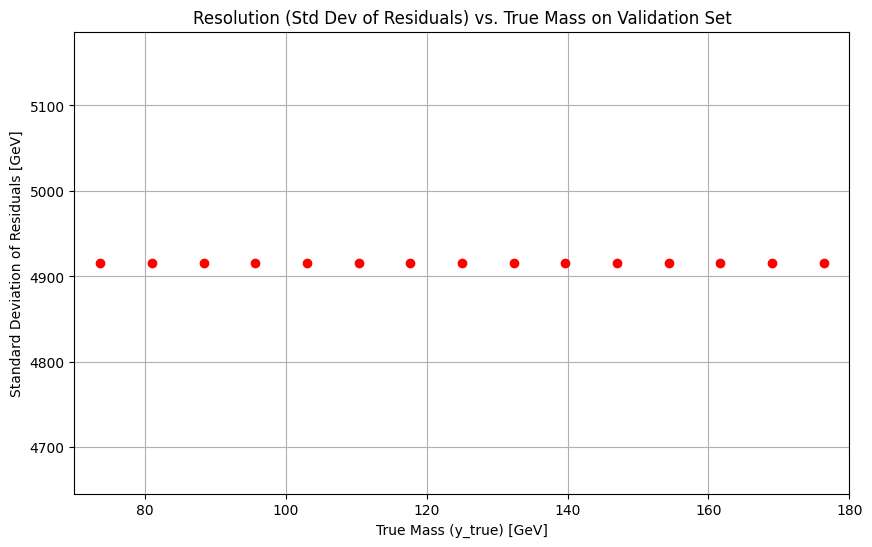

In [9]:
from scipy import stats # You need scipy for binned_statistic

# Assuming y_true and y_pred are your NumPy arrays of true and predicted values
if len(y_true) != len(y_pred):
    raise ValueError("y_true and y_pred must have the same length")

# Calculate the residuals
residuals = y_true - y_pred

# Define the number of intervals for y_true and the bin edges
n_intervals = 15 # Adjust as needed
true_mass_bins = np.linspace(70.0, 180.0, n_intervals + 1)

# 2. Calculate the standard deviation of residuals within each bin of y_true
std_residuals_per_bin, _, _ = stats.binned_statistic(
    y_true,           # The data to bin by (y_true values)
    residuals,        # The data on which to calculate the statistic (the residuals)
    statistic='std',  # Compute the standard deviation for each bin
    bins=true_mass_bins # The edges defining the bins for y_true
)

# 3. Count the number of samples within each bin of y_true
std_count_per_bin, _, _ = stats.binned_statistic(
    y_true,           # The data to bin by (y_true values)
    y_true,           # The data to count (can be y_true or residuals, doesn't matter for count)
    statistic='count',# Compute the count for each bin
    bins=true_mass_bins # The edges defining the bins for y_true
)

std_residuals_per_bin = std_count_per_bin[0] # Array of std devs
count_per_bin = std_count_per_bin[1].astype(float) # Array of counts

# Calculate the center of each bin for the x-axis
bin_centers = (true_mass_bins[:-1] + true_mass_bins[1:]) / 2

# Filter out bins with insufficient data (e.g., count <= 1, as std dev is NaN)
valid_indices = count_per_bin > 1

valid_bin_centers = bin_centers[valid_indices]
valid_std_residuals = std_residuals_per_bin[valid_indices]
valid_counts = count_per_bin[valid_indices] # Keep counts for potential future use (e.g., weighting)


plt.figure(figsize=(10, 6))

# Plot the standard deviation of residuals vs. true mass bin center
# Use markers to show discrete points
plt.plot(valid_bin_centers, valid_std_residuals, marker='o', linestyle='-', color='red')

plt.xlabel("True Mass (y_true) [GeV]")
plt.ylabel("Standard Deviation of Residuals [GeV]")
plt.title("Resolution (Std Dev of Residuals) vs. True Mass on Validation Set")
plt.grid(True)

# Optional: Set x-axis limits to match the mass range
plt.xlim(70, 180)

plt.savefig("residual_std_vs_true_mass.png", dpi=300)

# If you want to display the plot immediately
# plt.show()

/tmp/ipykernel_366887/301262127.py:30: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot(plot_limits, plot_limits, 'k--', lw=1.5, label='Ideal Prediction (y_pred = y_true)', color='red')


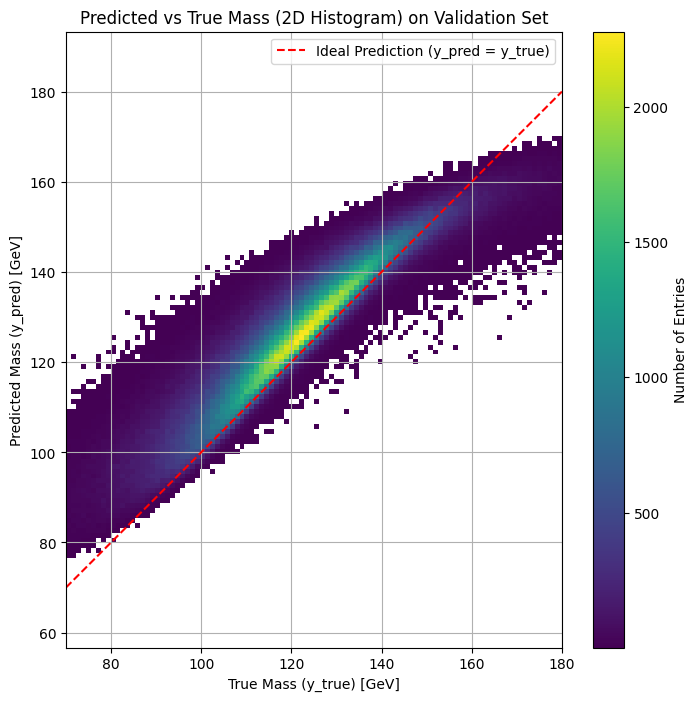

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming y_true and y_pred are your NumPy arrays of true and predicted values
if len(y_true) != len(y_pred):
    raise ValueError("y_true and y_pred must have the same length")

plt.figure(figsize=(8, 8)) # Make it square for better diagonal visualization

# Define bins for the 2D histogram. Use the same range for both axes.
# You can use the same bins as your 1D mass histograms.
hist_bins_1d = np.linspace(70.0, 180.0, 101) # Example: 100 bins for 2D plot

# Create the 2D histogram
# hist2d returns H (the histogram counts), xedges, yedges
H, xedges, yedges, img = plt.hist2d(
    y_true,     # Data for the x-axis
    y_pred,     # Data for the y-axis
    bins=hist_bins_1d, # Use the same bins for both x and y axes
    cmap='viridis', # Color map for density
    cmin=1 # Set cmin to avoid plotting empty bins (optional)
)

# Add a color bar to show the density scale
plt.colorbar(label='Number of Entries')

# Plot the diagonal line where y_pred == y_true (ideal prediction)
# Use the same limits as the plot axes
plot_limits = [min(xedges[0], yedges[0]), max(xedges[-1], yedges[-1])]
plt.plot(plot_limits, plot_limits, 'k--', lw=1.5, label='Ideal Prediction (y_pred = y_true)', color='red')

plt.xlabel("True Mass (y_true) [GeV]")
plt.ylabel("Predicted Mass (y_pred) [GeV]")
plt.title("Predicted vs True Mass (2D Histogram) on Validation Set")
plt.legend()
plt.grid(True)
plt.axis('equal') # Ensure the axes are scaled equally so the diagonal is 45 degrees
plt.xlim(70, 180)
plt.ylim(70, 180)

plt.savefig("predicted_vs_true_2d_histogram.png", dpi=300)

# If you want to display the plot immediately
# plt.show()

<Figure size 1000x600 with 0 Axes>

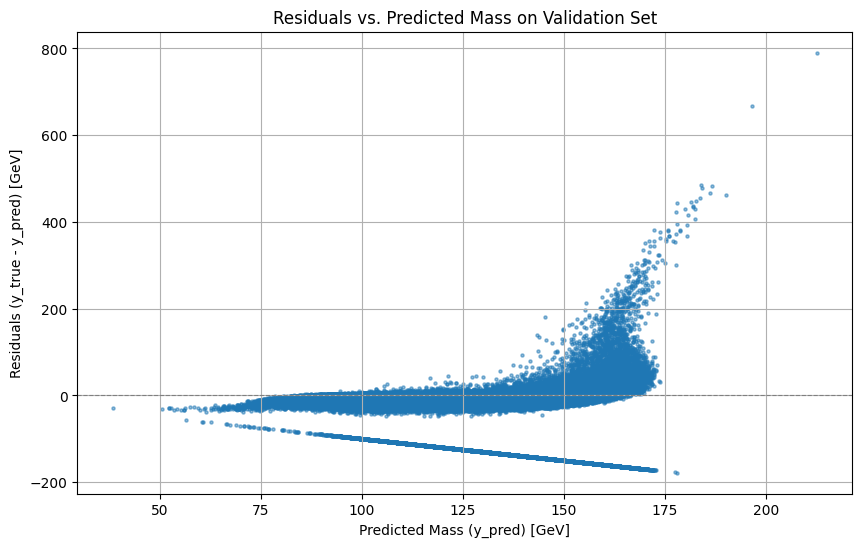

<Figure size 1000x600 with 0 Axes>

In [8]:
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns # Often used for residual plots with smoothing lines

# Assuming y_true and y_pred are your NumPy arrays of true and predicted values
if len(y_true) != len(y_pred):
    raise ValueError("y_true and y_pred must have the same length")

# Calculate the residuals
residuals = y_true - y_pred

plt.figure(figsize=(10, 6))

# Create a scatter plot of predicted values vs. residuals
# predicted values on the x-axis, residuals on the y-axis
plt.scatter(y_pred, residuals, alpha=0.5, s=5) # s is marker size, alpha for transparency

# Add a horizontal line at y=0
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)

plt.xlabel("Predicted Mass (y_pred) [GeV]")
plt.ylabel("Residuals (y_true - y_pred) [GeV]")
plt.title("Residuals vs. Predicted Mass on Validation Set")
plt.grid(True)

# Optional: Set limits for x-axis to match the predicted mass range
# plt.xlim(70, 180)
# Optional: Set limits for y-axis to focus on the main residual distribution
# plt.ylim(-50, 50)


plt.savefig("residuals_vs_predicted_plot.png", dpi=300)

# If you want to display the plot immediately
# plt.show()

# Using seaborn can sometimes add a useful smoothing line (Lowess)
plt.figure(figsize=(10, 6))
# sns.residplot(x=y_pred, y=residuals, lowess=True, scatter_kws={'alpha': 0.5, 's': 5}, line_kws={'color': 'red', 'lw': 1})
# plt.title("Residuals vs. Predicted Mass (with Lowess smoother)")
# plt.xlabel("Predicted Mass (y_pred) [GeV]")
# plt.ylabel("Residuals (y_true - y_pred) [GeV]")
# plt.grid(True)
# plt.savefig("residuals_vs_predicted_plot_seaborn.png", dpi=300)

In [ ]:
dataset = DatasetMass(file_paths=erik_data)
dataset.load_data(file_name = "data_mmc")
dataset.augment_data(n_slices = 20)

I0000 00:00:1747501374.457789  355359 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43428 MB memory:  -> device: 0, name: NVIDIA L40, pci bus id: 0000:21:00.0, compute capability: 8.9


Caching sampled data in memory.


In [4]:
param_grid = {
    'batch_size': [64, 6400],
    'learning_rate': [0.001, 0.1],
    'epochs': [1, 20, 30],
    "normalizer_samples": [1000]
}

iterable = list(itertools.product(*param_grid.values()))
for params in iterable:
    model = RegressionModel(dataset=dataset, batch_size=params[0], initial_learning_rate=params[1], n_epochs=params[2], normalizer_samples=params[3], augmentation_type = "lorentz")
    model.prepare_dataset()
    model.create_normalizer()
    model.build_model()
    model.train_model()
    model.plot_history()

Number of devices: 1
Batching datasets...


2025-05-17 19:02:57.447723: W tensorflow/core/kernels/data/cache_dataset_ops.cc:914] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-05-17 19:02:57.758734: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Building model...


I0000 00:00:1747501382.264927  355421 service.cc:148] XLA service 0x7f340801fb90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747501382.264959  355421 service.cc:156]   StreamExecutor device (0): NVIDIA L40, Compute Capability 8.9
2025-05-17 19:03:02.405140: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-05-17 19:03:02.611907: W tensorflow/compiler/tf2xla/kernels/random_ops.cc:61] Warning: Using tf.random.uniform with XLA compilation will ignore seeds; consider using tf.random.stateless_uniform instead if reproducible behavior is desired. functional_1/augmentation_1/random_uniform/RandomUniform
I0000 00:00:1747501383.084348  355421 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1747501385.289992  355421 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of th

   434/121859 ━━━━━━━━━━━━━━━━━━━━ 10:38:11 315ms/step - loss: 15251.6006 - mean_absolute_percentage_error: 95.8114 - mean_squared_error: 15251.6006

KeyboardInterrupt: 

In [ ]:
def objective(trial):

    model = RegressionModel(
                dataset,
                n_layers             = trial.suggest_int('n_layers', 2, 5),
                hidden_layer_size    = trial.suggest_int('hidden_layer_size', 512, 1024, step=128),
                initial_learning_rate= trial.suggest_float('initial_learning_rate', 1e-3, 1e-2, log=True),
                n_epochs             = trial.suggest_int('n_epochs', 100, 200, step=5),
                activation_function  = 'relu',
                batch_size           = trial.suggest_int('batch_size', 512, 1024,step=64),
                dropout_rate         = trial.suggest_float('dropout_rate', 0.1, 0.5),
                weight_decay         = trial.suggest_float('weight_decay', 1e-5, 1e-4, log=True)
            )

    model.prepare_dataset()
    model.create_normalizer()
    model.build_model()
    model.train_model()

    # Handle based on the number of metrics
    evaluation_results = model.model.evaluate(model.dev_batch, verbose=0)
    if isinstance(evaluation_results, list):
        val_loss = evaluation_results[0]
    else:
        val_loss = evaluation_results  # If only one value is returned, it's the loss

    return val_loss

study = optuna.create_study(storage="sqlite:///optuna.db", study_name="Higgs_analysis_mass_2", direction='minimize', load_if_exists=True)

def run_dashboard():
    server = run_server("sqlite:///optuna.db", host="0.0.0.0", port=8080)
    server.run()  # Run dashboard continuously in a separate thread

dashboard_thread = threading.Thread(target=run_dashboard)
dashboard_thread.daemon = True  # Ensures it stops when the script ends
dashboard_thread.start()

def run_optuna():
    study.optimize(objective, n_trials=100, n_jobs=1)

# Run Optuna in a separate thread so the dashboard can be accessed in real-time
optuna_thread = threading.Thread(target=run_optuna)
optuna_thread.start()

optuna_thread.join()  # Wait for Optuna to finish before printing results
print("Number of finished trials:", len(study.trials))
print("Best trial:", study.best_trial.params)



[I 2025-03-25 23:41:16,016] Using an existing study with name 'Higgs_analysis_mass_2' instead of creating a new one.
Bottle v0.13.2 server starting up (using WSGIRefServer())...
Listening on http://0.0.0.0:8080/
Hit Ctrl-C to quit.



Batching datasets...


2025-03-25 23:41:16.510918: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Building model...
Epoch 1/20


I0000 00:00:1742942477.678492 2786360 service.cc:148] XLA service 0x7f7c1c005ec0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1742942477.678524 2786360 service.cc:156]   StreamExecutor device (0): NVIDIA L40S, Compute Capability 8.9
2025-03-25 23:41:17.711543: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1742942477.828448 2786360 cuda_dnn.cc:529] Loaded cuDNN version 90300


...

12185/12185 ━━━━━━━━━━━━━━━━━━━━ 12s 924us/step - loss: 1592.9148 - mean_absolute_percentage_error: 101.2956 - mean_squared_error: 1592.9148 - val_loss: 707.6653 - val_mean_absolute_percentage_error: 7.4744 - val_mean_squared_error: 707.9465
Epoch 3/20
12185/12185 ━━━━━━━━━━━━━━━━━━━━ 100s 8ms/step - loss: 536.9959 - mean_absolute_percentage_error: 10.2609 - mean_squared_error: 536.9961 - val_loss: 681.8136 - val_mean_absolute_percentage_error: 7.7511 - val_mean_squared_error: 682.0729
Epoch 4/20
12185/12185 ━━━━━━━━━━━━━━━━━━━━ 11s 896us/step - loss: 1529.3429 - mean_absolute_percentage_error: 102.1909 - mean_squared_error: 1529.3429 - val_loss: 716.2120 - val_mean_absolute_percentage_error: 8.5863 - val_mean_squared_error: 716.4556
Epoch 5/20
 8609/12185 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 475.4726 - mean_absolute_percentage_error: 9.7364 - mean_squared_error: 475.4728

KeyboardInterrupt: 

 8610/12185 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 475.4728 - mean_absolute_percentage_error: 9.7364 - mean_squared_error: 475.4730

 9085/12185 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 475.6042 - mean_absolute_percentage_error: 9.7359 - mean_squared_error: 475.6045

[W 2025-03-25 23:46:08,653] Trial 50 failed with parameters: {'n_layers': 2, 'hidden_layer_size': 768, 'initial_learning_rate': 0.0034933707772084595, 'n_epochs': 20, 'batch_size': 640, 'dropout_rate': 0.39597475121024717, 'weight_decay': 9.481872484282561e-05} because of the following error: ZMQError('Socket operation on non-socket').
Traceback (most recent call last):
  File "/singularity/ucjf/venv_tf_218/lib64/python3.9/site-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_2786236/4236431915.py", line 19, in objective
    model.train_model()
  File "/home/ivanpa/HiggsAnalysisBc/ModelClass.py", line 138, in train_model
    history = self.model.fit(
  File "/singularity/ucjf/venv_tf_218/lib64/python3.9/site-packages/keras/src/utils/traceback_utils.py", line 122, in error_handler
    raise e.with_traceback(filtered_tb) from None
  File "/singularity/ucjf/venv_tf_218/lib64/python3.9/site-packages/ipykernel/iostream.py"